In [1]:
# Cornell notes — three densities (regular / extra / super).
# Lined baselines PLUS a vertical cue-column divider (~25% from left)
# and a horizontal summary-band divider (~20% from bottom). Both
# dividers land on lattice lines so everything is pixel-aligned.
# Like lined, line 0 is skipped (first writable row gets full SPACING
# of space below the header). The cue divider still extends all the way
# up to the header so the cue column is a full-height writing zone.
# Output: ../output/cornell/{cornell,extra-cornell,super-cornell}.png
from PIL import Image
from IPython.display import display
from common import (
    blank_page, draw_header, hline, vline, ELEM_SIZE, HEADER_HEIGHT,
    grid_counts, lattice_x, lattice_y,
    output_path, variant_name, DENSITIES,
)

MODE = "cornell"

# (cue_col, summary_row) per density. Snapped to lattice indices closest
# to 25% width / 80% height.
DIVIDERS = {
    "regular": (8,  34),   # cue 2000 px (24.2%), summary at 80.9%
    "extra":   (14, 56),   # cue 2100 px (25.4%), summary at 79.9%
    "super":   (17, 67),   # cue 2125 px (25.7%), summary at 79.7%
}

In [2]:
def render_cornell(spacing, cue_col, summary_row):
    """Lined background (skipping j=0) + vertical cue divider + summary
    horizontal divider. Cue divider extends from the header's bottom edge
    down to the summary row so the cue column is a full-height zone."""
    img = blank_page()
    n_x, n_y = grid_counts(spacing)
    for j in range(1, n_y):
        hline(img, lattice_y(j, spacing))
    vline(
        img,
        lattice_x(cue_col, spacing),
        top=HEADER_HEIGHT,
        bottom=lattice_y(summary_row, spacing) + ELEM_SIZE - 1,
    )
    draw_header(img)
    return img, n_x, n_y - 1

regular  spacing=250px  34 cols × 42 lines  cue@col 8  summary@row 34  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/cornell/cornell.png


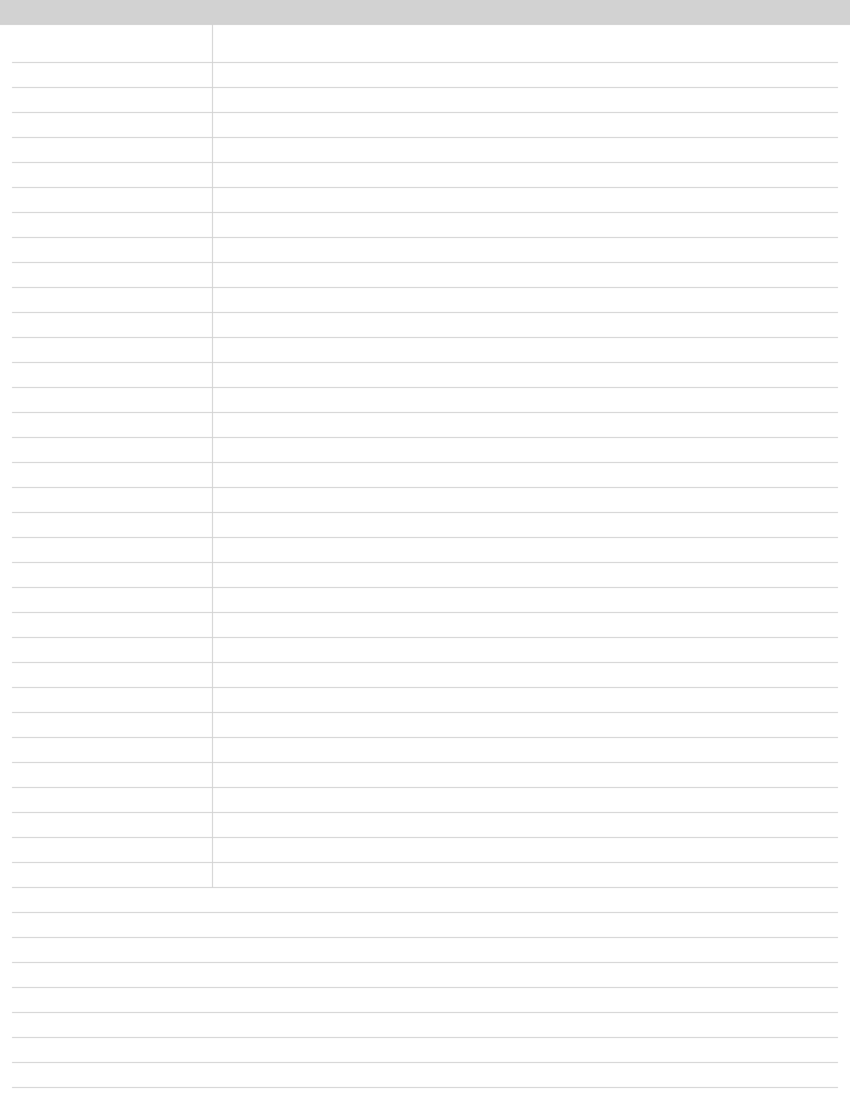

extra    spacing=150px  56 cols × 70 lines  cue@col 14  summary@row 56  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/cornell/extra-cornell.png


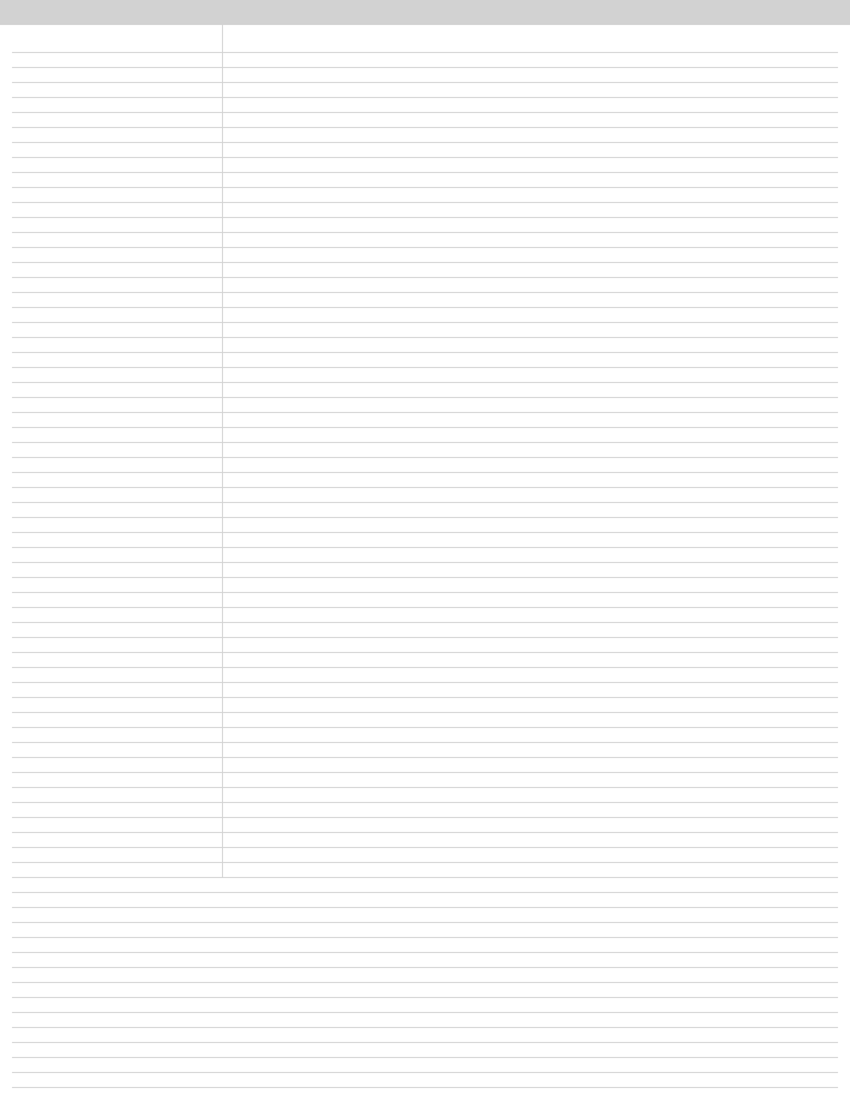

super    spacing=125px  67 cols × 84 lines  cue@col 17  summary@row 67  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/cornell/super-cornell.png


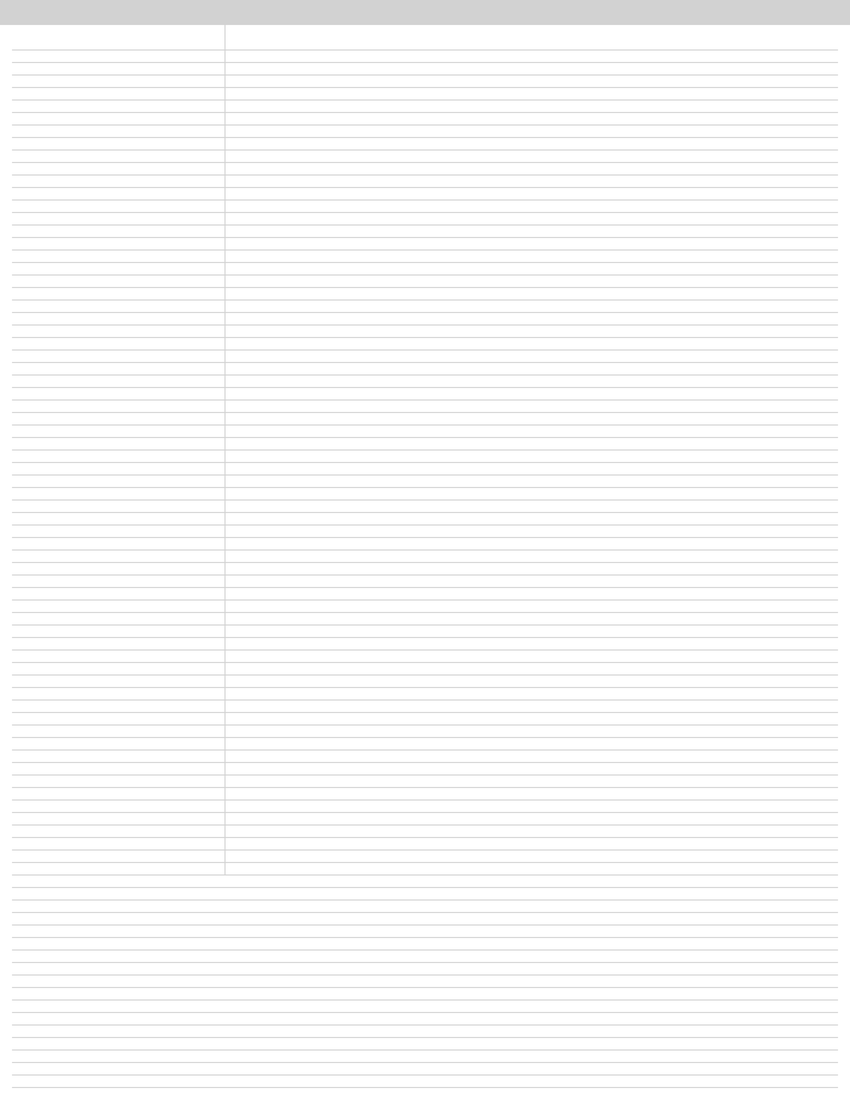

In [3]:
for density, spacing in DENSITIES.items():
    cue_col, summary_row = DIVIDERS[density]
    img, n_x, n_lines = render_cornell(spacing, cue_col, summary_row)
    path = output_path(MODE, variant_name(MODE, density))
    img.save(path, "PNG")
    print(
        f"{density:8s} spacing={spacing:3d}px  {n_x} cols × {n_lines} lines  "
        f"cue@col {cue_col}  summary@row {summary_row}  →  {path}"
    )
    display(img.resize((850, 1100), Image.LANCZOS))